<a href="https://colab.research.google.com/github/altburak/SCA-AGENT/blob/main/Video_kalite_artt%C4%B1r%C4%B1c%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# @title
# Clone Real-ESRGAN and enter the Real-ESRGAN
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN
# Set up the environment
!pip install basicsr
!pip install facexlib
!pip install gfpgan
!pip install ffmpeg-python
!pip install -r requirements.txt
!python setup.py develop

from IPython.display import HTML
from base64 import b64encode

def show_video(video_path, video_width = 720):

  video_file = open(video_path, "r+b").read()

  video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
  return HTML(f"""<video width={video_width} controls><source src="{video_url}"></video>""")

Cloning into 'Real-ESRGAN'...
remote: Enumerating objects: 759, done.
remote: Total 759 (delta 0), reused 0 (delta 0), pack-reused 759 (from 1)
Receiving objects: 100% (759/759), 5.39 MiB | 31.16 MiB/s, done.
Resolving deltas: 100% (408/408), done.
/content/Real-ESRGAN/Real-ESRGAN
/usr/local/lib/python3.12/dist-packages/setuptools/__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)
running develop
/usr/local/lib/python3.12/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ************************************

In [9]:
import os

# Define the path to the file
file_path = "/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py"

# Read the content of the file
with open(file_path, 'r') as file:
    file_data = file.readlines()

# Modify the specific line
for i, line in enumerate(file_data):
    if 'from torchvision.transforms.functional_tensor import rgb_to_grayscale' in line:
        file_data[i] = 'from torchvision.transforms.functional import rgb_to_grayscale\n'
        break

# Write the modified content back to the file
with open(file_path, 'w') as file:
    file.writelines(file_data)

print("Modification applied successfully.")

Modification applied successfully.


In [18]:
import os

source = "video" # @param ["image", "video"]
input = "/content/Real-ESRGAN/inputs/selam.mp4" # @param {type:"string"} **YÜKLEDİĞİNİZ VİDEONUN YOLUNU BURAYA GİRİNİZ**
model = "RealESRGAN_x2plus" # @param ["RealESRGAN_x4plus", "RealESRGAN_x2plus", "RealESRNet_x4plus", "official ESRGAN_x4", "realesr-general-x4v3", "RealESRGAN_x4plus_anime_6B", "realesr-animevideov3"]
scale = 2 # @param {type:"slider", min:1, max:4, step:1}
face_enhance = False # @param {type:"boolean"}


if source=="image":
  code = "inference_realesrgan.py"
elif source =="video":
  code = "inference_realesrgan_video.py"

def generate_output_path(input_path):
    # Get the directory from the input path
    directory, _ = os.path.split(input_path)

    return directory

def generate_result_path(input_path):
    # Extract the directory and filename from the input path
    directory, filename = os.path.split(input_path)

    # Remove the extension from the filename
    filename_without_extension, extension = os.path.splitext(filename)

    # Create the output path by adding '_out' before the extension
    output_filename = filename_without_extension + "_out" + extension
    output_path = os.path.join(directory, output_filename)

    return output_path

output = generate_output_path(input)
result = generate_result_path(input)
print(output)
print(result)

/content/Real-ESRGAN/inputs
/content/Real-ESRGAN/inputs/selam_out.mp4


In [19]:
if face_enhance == True:
  command = f"python '{code}' -i '{input}' -n '{model}' -o '{output}' -s '{scale}' --face_enhance"
elif face_enhance == False:
  command = f"python '{code}' -i '{input}' -n '{model}' -o '{output}' -s '{scale}'"
!{command}
# -h                   show this help
# -i input-path        input image path (jpg/png/webp) or directory
# -o output-path       output image path (jpg/png/webp) or directory
# -s scale             upscale ratio (can be 2, 3, 4. default=4)
# -t tile-size         tile size (>=32/0=auto, default=0) can be 0,0,0 for multi-gpu
# -m model-path        folder path to the pre-trained models. default=models
# -n model-name        model name (default=realesr-animevideov3, can be realesr-animevideov3 | realesrgan-x4plus | realesrgan-x4plus-anime | realesrnet-x4plus)
# -g gpu-id            gpu device to use (default=auto) can be 0,1,2 for multi-gpu
# -j load:proc:save    thread count for load/proc/save (default=1:2:2) can be 1:2,2,2:2 for multi-gpu
# -x                   enable tta mode"
# -f format            output image format (jpg/png/webp, default=ext/png)
# -v                   verbose output

Downloading: "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.1/RealESRGAN_x2plus.pth" to /content/Real-ESRGAN/Real-ESRGAN/weights/RealESRGAN_x2plus.pth

100% 64.0M/64.0M [00:00<00:00, 83.4MB/s]
inference: 100% 120/120 [02:51<00:00,  1.43s/frame]


In [16]:
# Install ffmpeg
!apt-get update -qq
!apt-get install -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 164 not upgraded.


In [12]:
# input video
show_video(input)

In [13]:
# enhanced video
show_video(result)

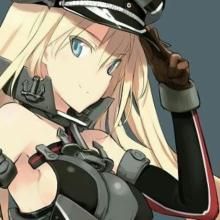

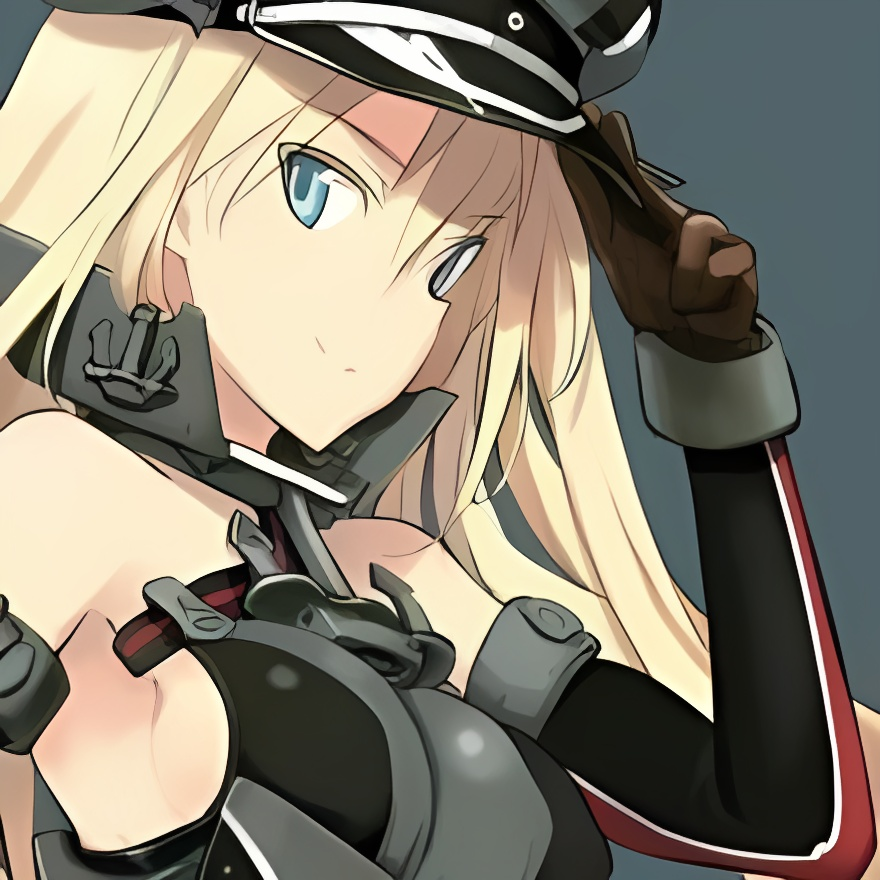

In [14]:
from IPython.display import Image, display

display(Image(filename=input, width=720))
display(Image(filename=result, width=720))